# Initial Data Analysis and EDA

This notebook explores the CM1 software metrics dataset and its `defects` target. It summarizes data quality, class balance, metric distributions, and numeric correlations. It does not train a machine-learning model or change the source CSV.

## Load the Data

Import the analysis libraries and load the existing CSV. The path check supports running the notebook from either the project folder or the `notebooks` folder.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid")

possible_paths = [Path("data/cm1.csv"), Path("../data/cm1.csv")]
data_path = next((path for path in possible_paths if path.is_file()), None)
if data_path is None:
    raise FileNotFoundError("Could not find data/cm1.csv. Run from the project folder or notebooks folder.")

df = pd.read_csv(data_path)
target_column = "defects"
if target_column not in df.columns:
    raise KeyError(f"Expected target column '{target_column}' was not found.")

print(f"Loaded: {data_path.resolve()}")
print(f"Rows: {len(df):,} | Columns: {len(df.columns):,}")
display(df.head(10))

Loaded: E:\software-defect-prediction\data\cm1.csv
Rows: 498 | Columns: 22


,loc,v(g),ev(g),iv(g),n,v,l,d,i,e,...,lOCode,lOComment,lOBlank,locCodeAndComment,uniq_Op,uniq_Opnd,total_Op,total_Opnd,branchCount,defects
0,1.1,1.4,1.4,1.4,1.3,1.30,1.30,1.30,1.30,1.30,...,2,2,2,2,1.2,1.2,1.2,1.2,1.4,False
1,1.0,1.0,1.0,1.0,1.0,1.00,1.00,1.00,1.00,1.00,...,1,1,1,1,1.0,1.0,1.0,1.0,1.0,True
2,24.0,5.0,1.0,3.0,63.0,309.13,0.11,9.50,32.54,2936.77,...,1,0,6,0,15.0,15.0,44.0,19.0,9.0,False
3,20.0,4.0,4.0,2.0,47.0,215.49,0.06,16.00,13.47,3447.89,...,0,0,3,0,16.0,8.0,31.0,16.0,7.0,False
4,24.0,6.0,6.0,2.0,72.0,346.13,0.06,17.33,19.97,5999.58,...,0,0,3,0,16.0,12.0,46.0,26.0,11.0,False
5,24.0,6.0,6.0,2.0,72.0,346.13,0.06,17.33,19.97,5999.58,...,0,0,3,0,16.0,12.0,46.0,26.0,11.0,False
6,7.0,1.0,1.0,1.0,11.0,34.87,0.50,2.00,17.43,69.74,...,0,0,1,0,4.0,5.0,6.0,5.0,1.0,False
7,12.0,2.0,1.0,2.0,23.0,94.01,0.16,6.43,14.62,604.36,...,0,0,7,0,10.0,7.0,14.0,9.0,3.0,False
8,25.0,5.0,5.0,5.0,107.0,548.83,0.07,14.25,38.51,7820.87,...,12,16,13,0,15.0,20.0,69.0,38.0,9.0,False
9,46.0,15.0,3.0,1.0,239.0,1362.41,0.04,22.30,61.10,30377.95,...,8,35,22,0,15.0,37.0,129.0,110.0,29.0,False


## Dataset Overview

Check the dataset dimensions, field names, and inferred data types before interpreting the metrics.

In [2]:
print("Dataset shape (rows, columns):", df.shape)
print("\nColumn names:")
print(df.columns.tolist())
print("\nColumn data types:")
display(df.dtypes.rename("data_type").to_frame())

Dataset shape (rows, columns): (498, 22)

Column names:
['loc', 'v(g)', 'ev(g)', 'iv(g)', 'n', 'v', 'l', 'd', 'i', 'e', 'b', 't', 'lOCode', 'lOComment', 'lOBlank', 'locCodeAndComment', 'uniq_Op', 'uniq_Opnd', 'total_Op', 'total_Opnd', 'branchCount', 'defects']

Column data types:


,data_type
loc,float64
v(g),float64
ev(g),float64
iv(g),float64
n,float64
v,float64
l,float64
d,float64
i,float64
e,float64


## Data Quality and Descriptive Statistics

Review missing values, exact duplicate rows, and numeric/categorical summary statistics. Duplicate rows are reported but the source data is not altered.

In [3]:
missing_by_column = df.isna().sum()
missing_total = int(missing_by_column.sum())

display(missing_by_column.rename("missing_values").to_frame())
print(f"Total missing values: {missing_total:,}")
print(f"Duplicate rows: {int(df.duplicated().sum()):,}")

print("\nDescriptive statistics:")
display(df.describe(include="all").T)

,missing_values
loc,0
v(g),0
ev(g),0
iv(g),0
n,0
v,0
l,0
d,0
i,0
e,0


Total missing values: 0
Duplicate rows: 56

Descriptive statistics:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
loc,498.0,NaN,NaN,NaN,29.644779,42.753572,1.0,8.0,17.0,31.0,423.0
v(g),498.0,NaN,NaN,NaN,5.382329,8.347359,1.0,1.0,3.0,6.0,96.0
ev(g),498.0,NaN,NaN,NaN,2.490763,3.658847,1.0,1.0,1.0,1.0,30.0
iv(g),498.0,NaN,NaN,NaN,3.528916,5.464398,1.0,1.0,2.0,4.0,63.0
n,498.0,NaN,NaN,NaN,143.956426,221.049888,1.0,25.0,67.5,151.75,2075.0
v,498.0,NaN,NaN,NaN,900.175823,1690.814334,0.0,102.19,329.82,861.46,17124.28
l,498.0,NaN,NaN,NaN,0.146325,0.159337,0.0,0.05,0.09,0.1775,1.3
d,498.0,NaN,NaN,NaN,15.829378,15.33096,0.0,5.63,11.64,21.1425,125.77
i,498.0,NaN,NaN,NaN,38.455361,36.996297,0.0,16.21,27.4,46.9,293.68
e,498.0,NaN,NaN,NaN,34884.932329,134164.665592,0.0,606.17,3677.62,16633.3375,2153690.63


## Target Distribution and Class Balance

Show the target's observed values and counts. For a binary target, this section also reports the minority-class share and flags imbalance when one class makes up at least 60% of the records (a practical descriptive threshold, not a modeling rule).

In [4]:
target_counts = df[target_column].value_counts(dropna=False)
target_distribution = pd.DataFrame({
    "count": target_counts,
    "percentage": (target_counts / len(df) * 100).round(2),
})

print("Unique target values:")
print(df[target_column].unique().tolist())
print("\nTarget class distribution:")
display(target_distribution)

if len(target_counts) == 2:
    majority_share = float(target_counts.max() / target_counts.sum())
    minority_share = float(target_counts.min() / target_counts.sum())
    class_ratio = float(target_counts.max() / target_counts.min())
    is_imbalanced = majority_share >= 0.60
    print(f"Minority class share: {minority_share:.1%}")
    print(f"Majority-to-minority ratio: {class_ratio:.2f}:1")
    print(f"Class imbalance (majority share >= 60%): {'Yes' if is_imbalanced else 'No'}")
else:
    majority_share = float(target_counts.max() / target_counts.sum())
    minority_share = float(target_counts.min() / target_counts.sum())
    class_ratio = np.nan
    is_imbalanced = majority_share >= 0.60
    print(f"Largest class share: {majority_share:.1%}")
    print(f"Class imbalance (largest share >= 60%): {'Yes' if is_imbalanced else 'No'}")

Unique target values:
[False, True]

Target class distribution:


,count,percentage
defects,,
False,449,90.16
True,49,9.84


Minority class share: 9.8%
Majority-to-minority ratio: 9.16:1
Class imbalance (majority share >= 60%): Yes


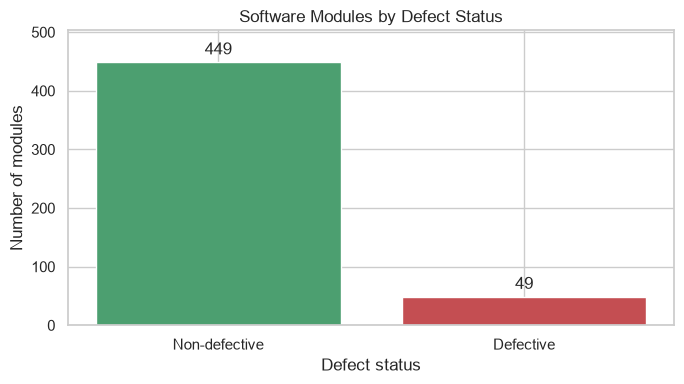

In [5]:
def display_class_name(value):
    normalized = str(value).strip().lower()
    if normalized in {"true", "1", "yes", "defective"}:
        return "Defective"
    if normalized in {"false", "0", "no", "non-defective", "non defective"}:
        return "Non-defective"
    return str(value)

class_labels = [display_class_name(value) for value in target_counts.index]
bar_colors = ["#c44e52" if label == "Defective" else "#4c9f70" for label in class_labels]
fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(class_labels, target_counts.values, color=bar_colors)
ax.set_title("Software Modules by Defect Status")
ax.set_xlabel("Defect status")
ax.set_ylabel("Number of modules")
ax.bar_label(bars, padding=3)
ax.set_ylim(0, max(target_counts.values) * 1.12)
plt.tight_layout()
plt.show()

## LOC, Complexity, and Branch Metrics

Metric names differ across datasets. The notebook searches column names without regard to punctuation or capitalization, then plots only available numeric columns and skips a category when no matching metric exists.

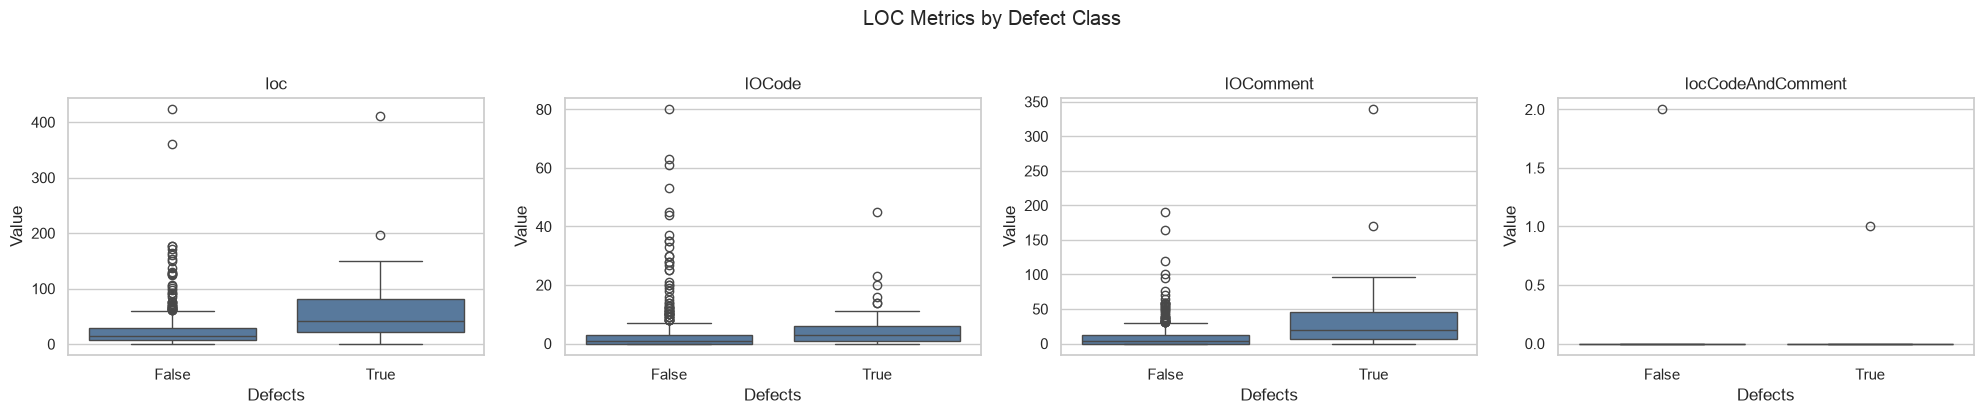

LOC metrics plotted: loc, lOCode, lOComment, locCodeAndComment


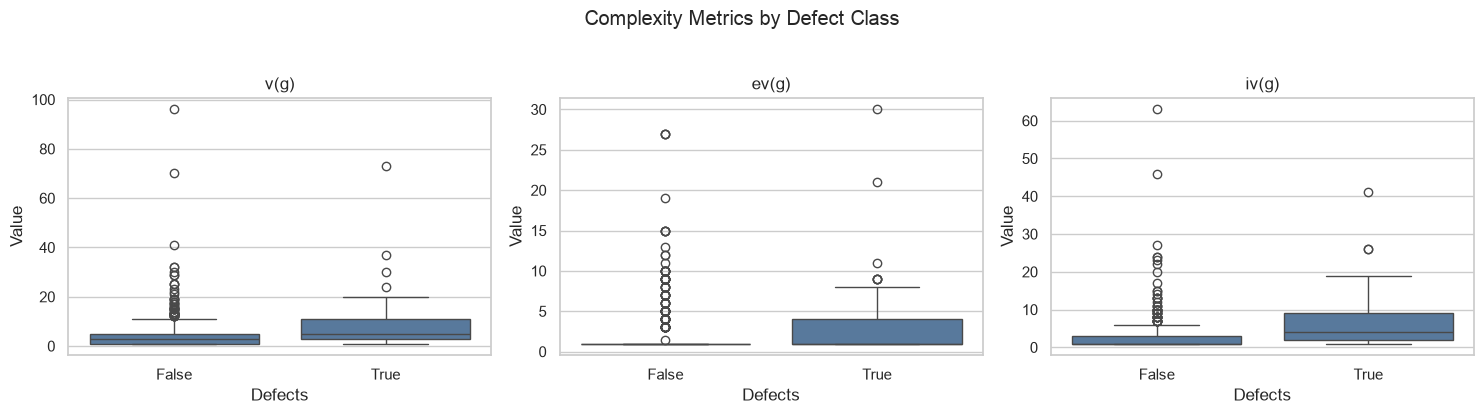

Complexity metrics plotted: v(g), ev(g), iv(g)


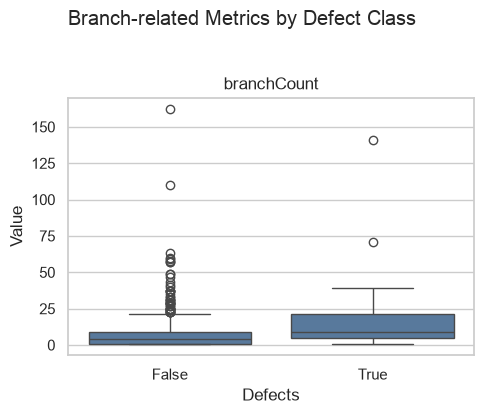

Branch-related metrics plotted: branchCount


In [6]:
import re

normalized_columns = {
    column: re.sub(r"[^a-z0-9]", "", str(column).lower())
    for column in df.columns
}
numeric_columns = df.select_dtypes(include=np.number).columns.tolist()

metric_groups = {"LOC": [], "Complexity": [], "Branch-related": []}
for column in numeric_columns:
    name = normalized_columns[column]
    if "loc" in name or "lineofcode" in name:
        metric_groups["LOC"].append(column)
    if name in {"vg", "evg", "ivg"} or "complex" in name or "cyclomatic" in name:
        metric_groups["Complexity"].append(column)
    if "branch" in name:
        metric_groups["Branch-related"].append(column)

for group_name, columns in metric_groups.items():
    columns = columns[:4]
    if not columns:
        print(f"No numeric {group_name.lower()} metrics found; skipping this plot.")
        continue

    figure, axes = plt.subplots(1, len(columns), figsize=(5 * len(columns), 4), squeeze=False)
    for axis, column in zip(axes[0], columns):
        sns.boxplot(data=df, x=target_column, y=column, color="#4c78a8", ax=axis)
        axis.set_title(str(column))
        axis.set_xlabel("Defects")
        axis.set_ylabel("Value")
    figure.suptitle(f"{group_name} Metrics by Defect Class", y=1.03)
    plt.tight_layout()
    plt.show()
    print(f"{group_name} metrics plotted: {', '.join(map(str, columns))}")

## Numeric Feature Correlations

Use a heatmap to inspect pairwise linear correlations among numeric columns. Correlation is descriptive and does not establish cause and effect.

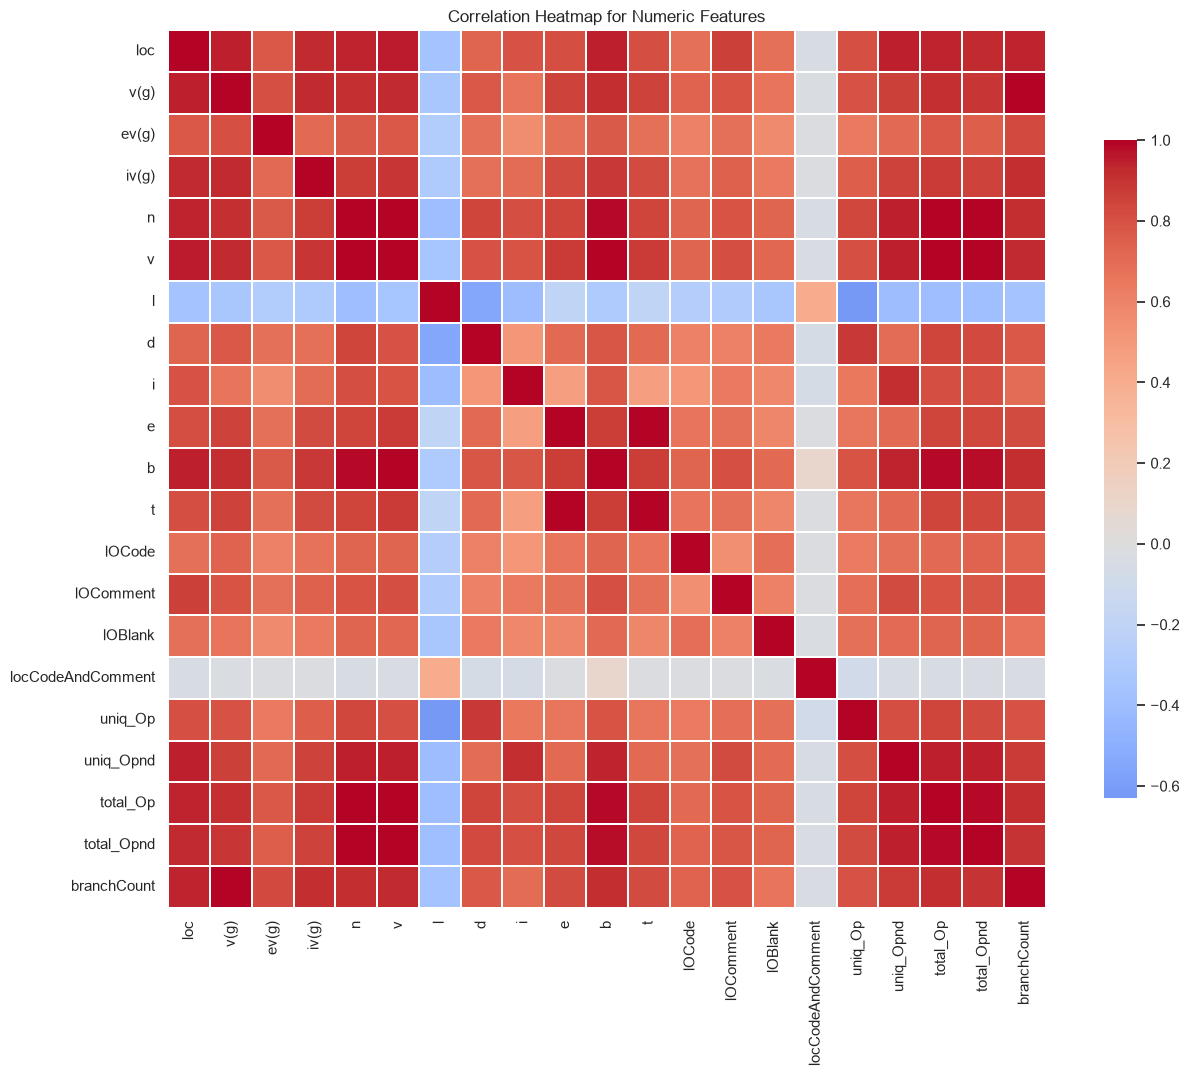

In [7]:
numeric_data = df.select_dtypes(include=np.number)
if numeric_data.shape[1] >= 2:
    correlation_matrix = numeric_data.corr()
    figure_size = max(8, min(16, 0.65 * len(correlation_matrix.columns)))
    plt.figure(figsize=(figure_size, figure_size * 0.8))
    sns.heatmap(
        correlation_matrix,
        cmap="coolwarm",
        center=0,
        square=True,
        linewidths=0.3,
        cbar_kws={"shrink": 0.75},
    )
    plt.title("Correlation Heatmap for Numeric Features")
    plt.tight_layout()
    plt.show()
else:
    print("At least two numeric columns are needed for a correlation heatmap.")

## What the EDA Shows

Summarize data quality and class balance, then report the strongest numeric association with the target if it can be calculated. These are descriptive findings, not predictions or causal conclusions.

In [8]:
duplicate_count = int(df.duplicated().sum())
strongest_metric = None
strongest_value = None
print(
    f"The dataset contains {len(df):,} modules and {len(df.columns):,} columns. "
    f"The target has {len(target_counts)} observed class(es); "
    f"the largest class contains {majority_share:.1%} of records."
)
if missing_total == 0:
    print("No missing values were found.")
else:
    print(f"{missing_total:,} missing values were found across {(missing_by_column > 0).sum()} column(s).")
print(f"There are {duplicate_count:,} exact duplicate row(s); they are reported but not removed.")

if len(numeric_data.columns) > 0 and target_counts.size > 1:
    encoded_target = df[target_column].astype("category").cat.codes
    target_correlations = numeric_data.drop(columns=[target_column], errors="ignore").apply(
        lambda column: column.corr(encoded_target)
    )
    target_correlations = target_correlations.dropna()
    if not target_correlations.empty:
        strongest_metric = target_correlations.abs().idxmax()
        strongest_value = target_correlations[strongest_metric]
        print(
            f"The strongest absolute numeric correlation with the encoded target is "
            f"{strongest_metric} ({strongest_value:.3f}). This is an association, not evidence of causation."
        )
    else:
        print("No usable numeric feature-to-target correlations could be calculated.")
else:
    print("There are not enough numeric features and target classes to calculate target correlations.")

available_metric_names = [
    f"{group}: {', '.join(map(str, columns[:4]))}"
    for group, columns in metric_groups.items()
    if columns
]
print("Detected metric groups: " + ("; ".join(available_metric_names) if available_metric_names else "none"))

The dataset contains 498 modules and 22 columns. The target has 2 observed class(es); the largest class contains 90.2% of records.
No missing values were found.
There are 56 exact duplicate row(s); they are reported but not removed.
The strongest absolute numeric correlation with the encoded target is lOComment (0.302). This is an association, not evidence of causation.
Detected metric groups: LOC: loc, lOCode, lOComment, locCodeAndComment; Complexity: v(g), ev(g), iv(g); Branch-related: branchCount


## Final Summary

Print a concise recap to keep the main dataset characteristics and EDA observations together at the end of the notebook.

In [9]:
print("=" * 60)
print("CM1 DATASET: FINAL EDA SUMMARY")
print("=" * 60)
print(f"Dataset size: {len(df):,} rows x {len(df.columns):,} columns")
print("Target distribution:")
for value, count in target_counts.items():
    percentage = count / len(df) * 100
    print(f"  {display_class_name(value)} ({value}): {count:,} ({percentage:.2f}%)")
print(f"Missing values: {missing_total:,} total across {(missing_by_column > 0).sum()} column(s)")
print(f"Exact duplicate rows: {duplicate_count:,}")
print(f"Class imbalance (majority class >= 60%): {'Yes' if is_imbalanced else 'No'}")

print("Important observations:")
if missing_total == 0:
    print("  - No missing values were detected.")
else:
    print(f"  - Missing data is present in {(missing_by_column > 0).sum()} column(s); inspect the quality table above.")
if duplicate_count:
    print(f"  - {duplicate_count:,} exact duplicate rows were found; the dataset was left unchanged.")
else:
    print("  - No exact duplicate rows were found.")
if is_imbalanced:
    print(f"  - The target is imbalanced: the minority class is {minority_share:.1%} of the dataset.")
else:
    print(f"  - The target does not meet the notebook's 60% imbalance threshold (minority share: {minority_share:.1%}).")
if strongest_metric is not None:
    print(f"  - Strongest absolute numeric target correlation: {strongest_metric} ({strongest_value:.3f}).")
if available_metric_names:
    print("  - Metric visualizations were generated for: " + "; ".join(available_metric_names) + ".")
else:
    print("  - No matching numeric LOC, complexity, or branch metrics were available to plot.")
print("  - Correlations describe associations and should not be interpreted as causal effects.")
print("=" * 60)

CM1 DATASET: FINAL EDA SUMMARY
Dataset size: 498 rows x 22 columns
Target distribution:
  Non-defective (False): 449 (90.16%)
  Defective (True): 49 (9.84%)
Missing values: 0 total across 0 column(s)
Exact duplicate rows: 56
Class imbalance (majority class >= 60%): Yes
Important observations:
  - No missing values were detected.
  - 56 exact duplicate rows were found; the dataset was left unchanged.
  - The target is imbalanced: the minority class is 9.8% of the dataset.
  - Strongest absolute numeric target correlation: lOComment (0.302).
  - Metric visualizations were generated for: LOC: loc, lOCode, lOComment, locCodeAndComment; Complexity: v(g), ev(g), iv(g); Branch-related: branchCount.
  - Correlations describe associations and should not be interpreted as causal effects.
